# Инференс на панораме — пример

Сегментация сульфидов + классификация типа срастаний на панорамном OM-изображении
шлифа, поверх обученных весов.

**Выход:** цветовая маска (🟢 зелёный = обычные срастания, 🔴 красный = тонкие) +
таблица площадных долей + пер-зёренная таблица уверенности.

Веса берутся из `miners/segmenter_weights.pt` и `miners/classifier_weights.pt`.
Порог классификатора задаётся вручную (в весах не было `decision.json`).

## 1. Пути и окружение

In [9]:
import sys, json, shutil, time, logging
from pathlib import Path

# найти корень проекта (папку с src/inference), из любого CWD
PROJECT = Path.cwd()
while not (PROJECT / "src" / "inference").is_dir() and PROJECT != PROJECT.parent:
    PROJECT = PROJECT.parent
assert (PROJECT / "src" / "inference").is_dir(), \
    "Запусти ноутбук внутри ML/sulfide_intergrowth"
sys.path.insert(0, str(PROJECT))

MINERS = PROJECT.parents[1]          # .../miners/ML/sulfide_intergrowth -> miners
print("project:", PROJECT)
print("miners :", MINERS)

project: /Users/den1shh/Documents/nornickel/miners/ML/sulfide_intergrowth
miners : /Users/den1shh/Documents/nornickel/miners


## 2. Конфиг (Hydra) и устройство

In [10]:
from hydra import compose, initialize_config_dir
from omegaconf import OmegaConf
from src.utils import resolve_path, get_device, setup_logging

setup_logging(logging.INFO)

with initialize_config_dir(version_base=None, config_dir=str(PROJECT / "run" / "conf")):
    cfg = compose(config_name="config")

# веса уже обучены — не тянем ImageNet-инициализацию при сборке моделей
cfg.model.segmenter.pretrained = False
cfg.model.classifier.pretrained = False

device = get_device(str(cfg.device))
print("device:", device)
print(OmegaConf.to_yaml(cfg.infer))

device: mps
seg_tile: 1024
seg_stride: 768
cls_tile: 448
cls_stride: 224
seg_threshold: 0.5
min_component_px: 96
smooth_components_below_px: 20000
overlay_alpha: 0.45
batch_size: 16
use_unet: true



## 3. Подготовка весов

Пайплайн ждёт в `weights/`: `segmenter_best.pt`, `classifier_best.pt`, `decision.json`.
Копируем загруженные веса под эти имена и задаём порог классификатора.

In [11]:
SEG_SRC = MINERS / "segmenter_weights.pt"
CLS_SRC = MINERS / "classifier_weights.pt"
assert SEG_SRC.is_file(), f"нет файла: {SEG_SRC}"
assert CLS_SRC.is_file(), f"нет файла: {CLS_SRC}"

WEIGHTS = resolve_path(cfg.paths.weights)      # ML/sulfide_intergrowth/weights
WEIGHTS.mkdir(parents=True, exist_ok=True)
shutil.copy(SEG_SRC, WEIGHTS / "segmenter_best.pt")
shutil.copy(CLS_SRC, WEIGHTS / "classifier_best.pt")

# Порог fine-vs-normal. В весах не было decision.json (нет val-подобранного порога),
# поэтому берём нейтральный 0.5. Если знаешь лучший порог с обучения — впиши сюда.
THRESHOLD = 0.5
(WEIGHTS / "decision.json").write_text(json.dumps({
    "threshold": THRESHOLD,
    "note": "threshold set manually in notebook (no decision.json shipped)",
}, indent=2))
print("weights ready ->", WEIGHTS)

weights ready -> /Users/den1shh/Documents/nornickel/miners/ML/sulfide_intergrowth/weights


## 4. Сборка пайплайна (загрузка весов)

In [12]:
from src.inference import PanoramaPipeline

pipe = PanoramaPipeline(cfg, WEIGHTS, device)
print("threshold:", pipe.threshold, "| U-Net:", pipe.segmenter is not None)

01:23:29 INFO src.inference.panorama: Segmenter loaded (val IoU=0.883)
01:23:41 INFO src.inference.panorama: Classifier loaded: classifier_best.pt
threshold: 0.5 | U-Net: True


## 5. Выбор панорамы

`QUICK_DEMO = True` — прогон на центральном кропе (быстро, ~секунды/минуты).
Поставь `False` для полной панорамы (~13k×10k, несколько минут на CPU/MPS).

In [13]:
import cv2

DATA = resolve_path(cfg.paths.data_root)
PANO = DATA / str(cfg.data.panoramas_dir) / "4.jpg"     # <-- поменяй на свой файл
assert PANO.is_file(), f"нет панорамы: {PANO}"

OUT = PROJECT / "run" / "outputs" / "notebook_demo"
OUT.mkdir(parents=True, exist_ok=True)

QUICK_DEMO = False
img_path = PANO
if QUICK_DEMO:
    full = cv2.imread(str(PANO))
    h, w = full.shape[:2]
    cy, cx = h // 2, w // 2
    crop = full[max(0, cy-1400):cy+1400, max(0, cx-2000):cx+2000]
    img_path = OUT / "pano_crop.jpg"
    cv2.imwrite(str(img_path), crop)
print("input:", img_path.name, "| shape:", cv2.imread(str(img_path)).shape)

input: 4.jpg | shape: (10798, 13712, 3)


## 6. Инференс

In [14]:
t0 = time.time()
class_map, table = pipe.run(img_path, OUT)   # пишет overlay/classmap/metrics/segments
print(f"готово за {time.time()-t0:.1f} c")
table

01:23:47 INFO src.inference.panorama: Panorama 4.jpg: 13712x10798
01:23:49 INFO src.inference.sliding_window: segmenter sliding window: 252 tiles (1024px / stride 768)
01:29:20 INFO src.inference.panorama: Sulfide fraction: 5.21%
01:29:20 INFO src.inference.sliding_window: classifier sliding window: 1823/2928 tiles carry sulfide
01:36:00 INFO src.inference.report: Segments: 2972 grains -> 4_segments.csv
01:36:00 INFO src.inference.report: Report saved to /Users/den1shh/Documents/nornickel/miners/ML/sulfide_intergrowth/run/outputs/notebook_demo (4_*)
готово за 733.7 c


,metric,value
0,"Общая доля сульфидов, % площади",5.2093
1,"Обычные срастания, % площади",0.9706
2,"Тонкие срастания, % площади",4.2386
3,"Обычные срастания, % от сульфидов",18.6326
4,"Тонкие срастания, % от сульфидов",81.3674


## 7. Цветовая маска поверх снимка

/var/folders/sg/qv2t2v2n6rv2lb0bxf8d_l680000gn/T/ipykernel_5750/3082611694.py:8: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/sg/qv2t2v2n6rv2lb0bxf8d_l680000gn/T/ipykernel_5750/3082611694.py:8: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/Users/den1shh/.pyenv/versions/3.12.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/den1shh/.pyenv/versions/3.12.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


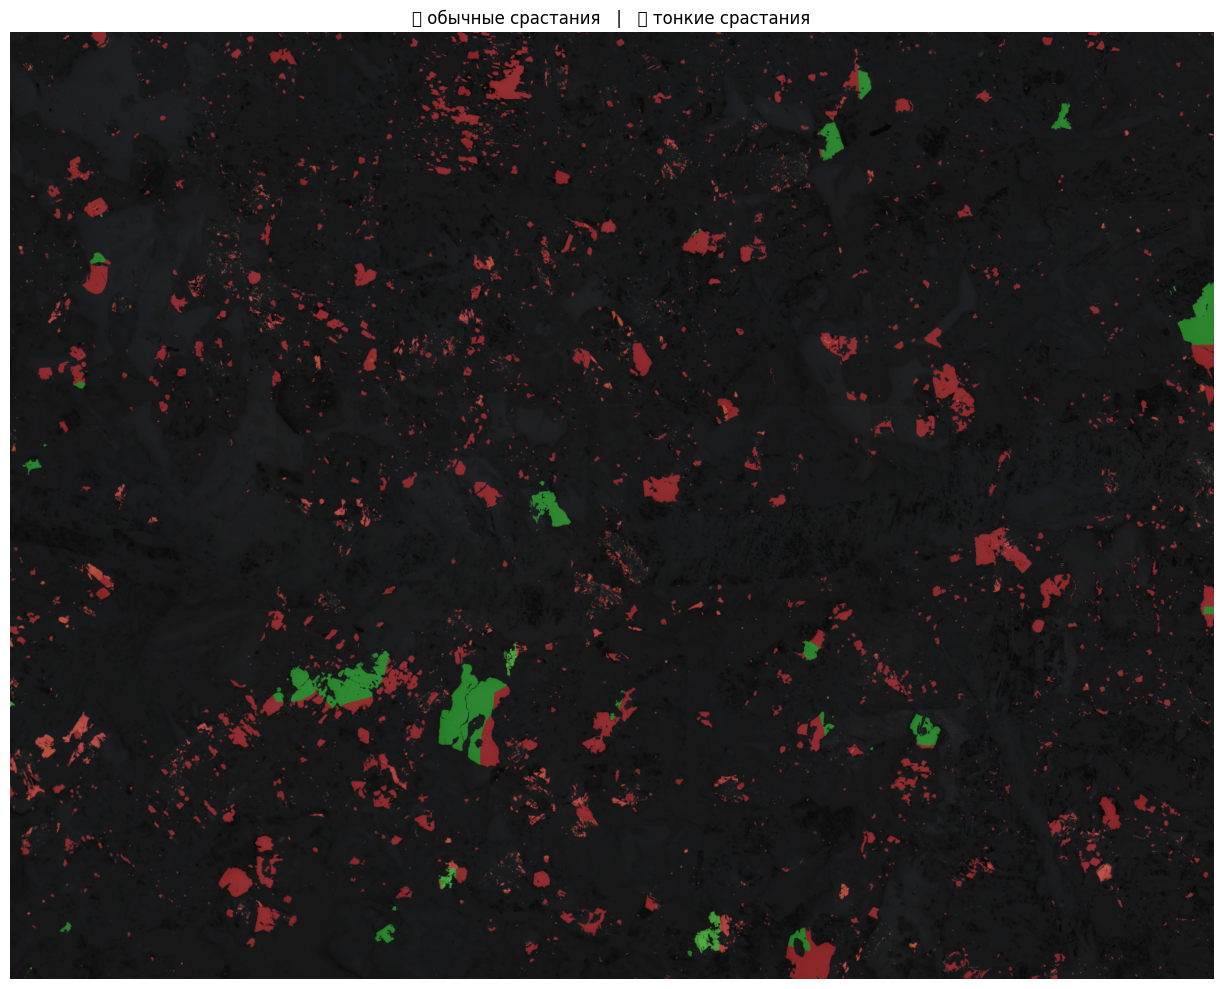

In [ ]:
import matplotlib.pyplot as plt

overlay = cv2.cvtColor(cv2.imread(str(OUT / f"{img_path.stem}_overlay.jpg")), cv2.COLOR_BGR2RGB)
plt.figure(figsize=(14, 10))https://file+.vscode-resource.vscode-cdn.net/var/folders/sg/qv2t2v2n6rv2lb0bxf8d_l680000gn/T/ipykernel_5750/3082611694.py:8
plt.imshow(overlay)
plt.axis("off")
plt.title("🟢 обычные срастания   |   🔴 тонкие срастания")
plt.tight_layout(); plt.show()

## 8. Пер-зёренная таблица (класс + уверенность)

In [16]:
import pandas as pd

seg = pd.read_csv(OUT / f"{img_path.stem}_segments.csv")
print(f"зёрен сульфидов: {len(seg)}")
seg.head(12)

зёрен сульфидов: 2972


,segment_id,class,area_px,area_pct,confidence,conf_sulfide,cx,cy
0,1989,normal,479356,0.32375,0.6331,0.9707,5279,7809
1,1950,normal,310193,0.20950,0.5112,0.9741,4029,7442
2,836,normal,235047,0.15875,0.5967,0.9660,13572,3392
3,2874,fine,200134,0.13517,0.6476,0.9629,9110,10553
4,1586,fine,153987,0.10400,0.8761,0.9727,11261,5917
5,1148,fine,117909,0.07963,0.7416,0.9718,10719,4064
6,126,fine,112590,0.07604,0.6675,0.9758,5681,601
7,1996,normal,107352,0.07250,0.5568,0.9727,3367,7485
8,1465,fine,92965,0.06279,0.6524,0.9708,7433,5210
9,1505,normal,90766,0.06130,0.6145,0.9706,6150,5438


## Файлы результата (`run/outputs/notebook_demo/`)

- `<имя>_overlay.jpg` — исходник с цветовой маской;
- `<имя>_classmap.png` — 0=фон, 1=обычные, 2=тонкие;
- `<имя>_metrics.csv|md` — доли по площади;
- `<имя>_segments.csv` — класс и уверенность по каждому зерну.

## То же из командной строки

```bash
cd run/pipeline
python infer_panorama.py +input=/path/to/panorama.jpg
```

(нужны те же `weights/segmenter_best.pt`, `weights/classifier_best.pt`, `weights/decision.json`).